---
## 1. Data Ingestion
Load the full 2025 season from Wyscout export. Both CofC and opponent rows are included — 16 matches, 32 rows total.

---
## 2. Feature Engineering
Build match-level features by merging CofC and opponent rows. Key features include differential metrics — xG diff, possession diff, pass accuracy diff — which capture relative performance rather than absolute numbers.

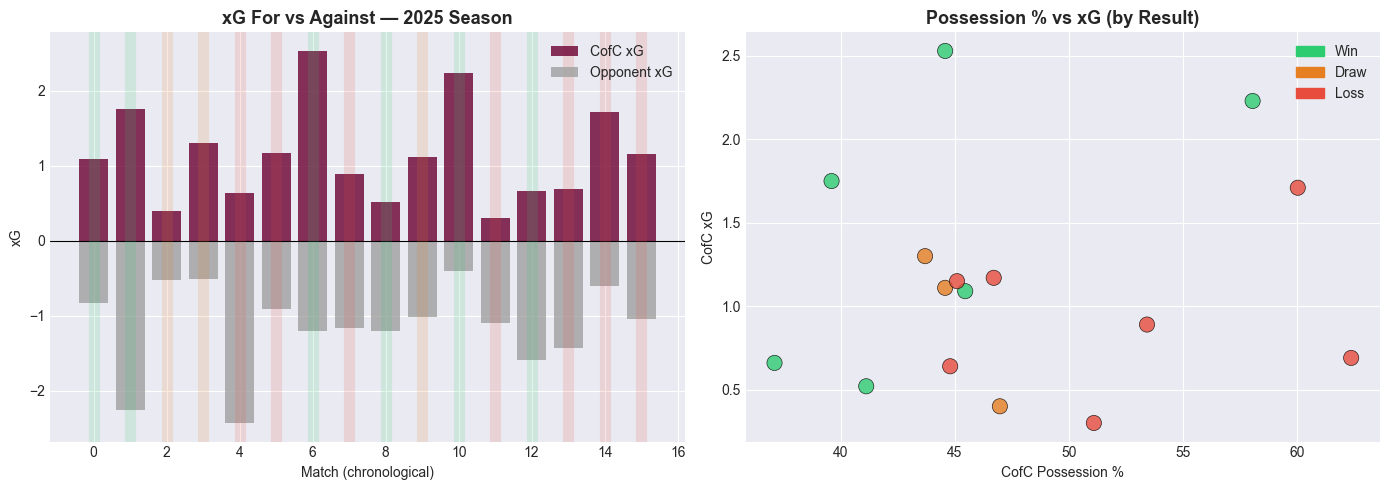

💡 Interesting: CofC often wins with LESS possession — defensive counter-attacking style?


In [7]:
# Visualize xG for vs against across the season
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# xG for vs against per match
ax1 = axes[0]
x = range(len(features))
ax1.bar(x, features['xg_cofc'], color=COFC_COLOR, alpha=0.8, label='CofC xG')
ax1.bar(x, -features['xg_opp'], color=OPP_COLOR, alpha=0.8, label='Opponent xG')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title('xG For vs Against — 2025 Season', fontsize=13, fontweight='bold')
ax1.set_ylabel('xG')
ax1.set_xlabel('Match (chronological)')
ax1.legend()
for i, row in features.iterrows():
    color = '#2ecc71' if row['result']=='W' else ('#e67e22' if row['result']=='D' else '#e74c3c')
    ax1.axvline(x=list(features.index).index(i), color=color, alpha=0.15, linewidth=8)

# Possession distribution
ax2 = axes[1]
ax2.scatter(features['possession_pct_cofc'], features['xg_cofc'],
            c=[('#2ecc71' if r=='W' else ('#e67e22' if r=='D' else '#e74c3c'))
               for r in features['result']],
            s=120, alpha=0.8, edgecolors='black', linewidth=0.5)
ax2.set_title('Possession % vs xG (by Result)', fontsize=13, fontweight='bold')
ax2.set_xlabel('CofC Possession %')
ax2.set_ylabel('CofC xG')
patches = [mpatches.Patch(color='#2ecc71', label='Win'),
           mpatches.Patch(color='#e67e22', label='Draw'),
           mpatches.Patch(color='#e74c3c', label='Loss')]
ax2.legend(handles=patches)

plt.tight_layout()
plt.savefig('../outputs/reports/season_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Interesting: CofC often wins with LESS possession — defensive counter-attacking style?')

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

X, y, feature_cols = prepare_features(features)
actuals, predictions = train_and_evaluate(X, y)
importance_df = get_feature_importance(X, y, feature_cols)

accuracy = accuracy_score(actuals, predictions)
print(f'LOO Cross-Validation Accuracy: {accuracy:.1%}')
print(f'Random baseline (3-class):     33.3%')
print(f'Improvement over baseline:     +{(accuracy - 0.333):.1%}')

LOO Cross-Validation Accuracy: 62.5%
Random baseline (3-class):     33.3%
Improvement over baseline:     +29.2%


---
## 4. Monte Carlo Simulation
Goals in football follow a **Poisson distribution** — discrete events with a known average rate. By sampling from Poisson(xG) 10,000 times per team, we get a full probability distribution over scorelines rather than a single point prediction.

This is the industry-standard approach used by professional prediction models.

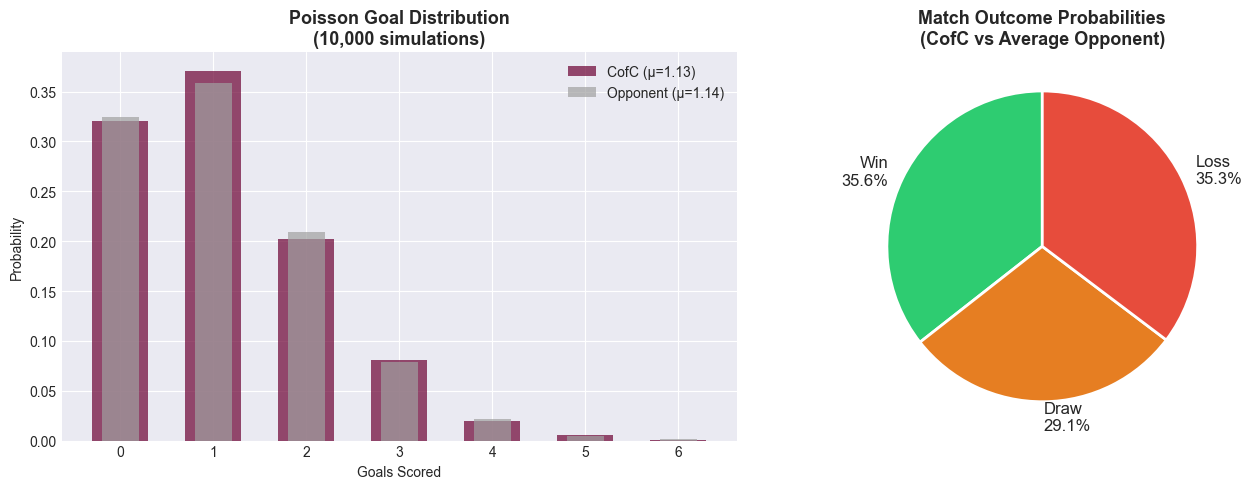

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Goal distribution
ax1 = axes[0]
bins = range(0, 8)
ax1.hist(cofc_goals, bins=bins, alpha=0.7, color=COFC_COLOR,
         label=f'CofC (μ={cofc_xg:.2f})', density=True, rwidth=0.6, align='left')
ax1.hist(opp_goals, bins=bins, alpha=0.7, color=OPP_COLOR,
         label=f'Opponent (μ={opp_xg:.2f})', density=True, rwidth=0.4, align='left')
ax1.set_title('Poisson Goal Distribution\n(10,000 simulations)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Goals Scored')
ax1.set_ylabel('Probability')
ax1.legend()

# Win/Draw/Loss probability pie
ax2 = axes[1]
sizes  = [win_pct, draw_pct, loss_pct]
labels = [f'Win\n{win_pct:.1%}', f'Draw\n{draw_pct:.1%}', f'Loss\n{loss_pct:.1%}']
colors = ['#2ecc71', '#e67e22', '#e74c3c']
wedges, texts = ax2.pie(sizes, labels=labels, colors=colors,
                         startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for text in texts:
    text.set_fontsize(12)
ax2.set_title('Match Outcome Probabilities\n(CofC vs Average Opponent)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/reports/monte_carlo.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
report = generate_scouting_report(
    features=features,
    opponent_name="William & Mary Tribe",
    opponent_xg_for=features['xg_opp'].mean(),
    opponent_xg_against=features['xg_cofc'].mean(),
    opponent_pass_acc=features['pass_accuracy_pct_opp'].mean(),
    opponent_possession=features['possession_pct_opp'].mean(),
    match_date="2025-11-08",
    n_simulations=10000
)
print(report)

  PRE-MATCH SCOUTING REPORT
  College of Charleston Cougars
  vs William & Mary Tribe
  2025-11-08

📊 COFC SEASON PROFILE
  Record:          6W - 3D - 7L
  Recent Form:     WWDDL
  Avg xG For:      1.13
  Avg xG Against:  1.14
  Avg Possession:  47.8%
  Avg Pass Acc:    76.7%
  Avg Recoveries:  91.6

🔎 OPPONENT PROFILE: William & Mary Tribe
  Avg xG For:      1.14
  Avg xG Against:  1.13
  Avg Possession:  52.2%
  Avg Pass Acc:    78.8%

🎲 MONTE CARLO SIMULATION (10,000 iterations)
  CofC Win:        35.3%
  Draw:            27.9%
  CofC Loss:       36.7%
  Expected Score:  CofC 1.1 - 1.2 William & Mary Tribe

  Most Likely Scorelines:
    1-1:  ██████ 13.1%
    0-1:  █████ 11.8%
    1-0:  █████ 11.5%
    0-0:  ████ 9.8%
    1-2:  ████ 8.1%

⚡ KEY MATCHUP INSIGHTS
  Possession:  Opponent advantage (47.8% vs 52.2%)
  Passing:     Opponent advantage (76.7% vs 78.8%)
  xG:          Opponent advantage (1.13 vs 1.14)

📋 TACTICAL NOTES
  ⚠ CofC generating less xG than conceding this season.
